# Diagnostic & Correction du Dataset — ValuSense
## Analyse post-nettoyage et recommandations

**Problème identifié :** Le dataset présente un déséquilibre extrême sur 3 classes
(DDM: 5, Mark-to-Market: 4, Relative: 3 en validation), ce qui signifie que le dataset
original contient très peu d'exemples de ces classes. Le SMOTE a sur-généré des
échantillons synthétiques à partir de quasi rien — c'est dangereux pour la qualité du modèle.


---
## 1. Diagnostic — Distribution Réelle (Avant Resampling)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIG_DIR = Path("reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Reconstituer la distribution originale ────────────────────
# La validation est stratifiee (80/20), donc on peut estimer l'original
val_counts = pd.Series({
    "DCF": 888, "Black-Scholes": 360, "Cost-of-Carry": 311,
    "Credit-Model": 309, "Forward-Pricing": 237, "Monte-Carlo": 232,
    "Binomial-Tree": 223, "DDM": 5, "Mark-to-Market": 4, "Relative": 3,
})

# Si split 80/20, original ≈ val × 5
estimated_original = (val_counts * 5).astype(int)
estimated_original.name = "Estimated Original Count"

print("=" * 60)
print("  DISTRIBUTION ESTIMEE DU DATASET ORIGINAL (avant SMOTE)")
print("=" * 60)
for method, count in estimated_original.sort_values(ascending=False).items():
    pct = count / estimated_original.sum() * 100
    bar = "█" * int(pct)
    flag = " ⚠️ CRITIQUE" if count < 100 else ""
    print(f"  {method:20s} : {count:6,} ({pct:5.1f}%) {bar}{flag}")

print(f"\n  Total estime : {estimated_original.sum():,}")
print(f"  Ratio d'imbalance : {estimated_original.max() / estimated_original.min():.0f}:1")

# Classes critiques
critical = estimated_original[estimated_original < 100]
print(f"\n  CLASSES CRITIQUES (< 100 echantillons) : {len(critical)}")
for cls, cnt in critical.items():
    print(f"    {cls} : ~{cnt} echantillons -> SMOTE a genere {3552 - cnt} = {3552-cnt} faux echantillons")
    print(f"      Ratio synthetique/reel : {(3552-cnt)/max(cnt,1):.0f}:1 -> DANGEREUX")

  DISTRIBUTION ESTIMEE DU DATASET ORIGINAL (avant SMOTE)
  DCF                  :  4,440 ( 34.5%) ██████████████████████████████████
  Black-Scholes        :  1,800 ( 14.0%) █████████████
  Cost-of-Carry        :  1,555 ( 12.1%) ████████████
  Credit-Model         :  1,545 ( 12.0%) ████████████
  Forward-Pricing      :  1,185 (  9.2%) █████████
  Monte-Carlo          :  1,160 (  9.0%) █████████
  Binomial-Tree        :  1,115 (  8.7%) ████████
  DDM                  :     25 (  0.2%)  ⚠️ CRITIQUE
  Mark-to-Market       :     20 (  0.2%)  ⚠️ CRITIQUE
  Relative             :     15 (  0.1%)  ⚠️ CRITIQUE

  Total estime : 12,860
  Ratio d'imbalance : 296:1

  CLASSES CRITIQUES (< 100 echantillons) : 3
    DDM : ~25 echantillons -> SMOTE a genere 3527 = 3527 faux echantillons
      Ratio synthetique/reel : 141:1 -> DANGEREUX
    Mark-to-Market : ~20 echantillons -> SMOTE a genere 3532 = 3532 faux echantillons
      Ratio synthetique/reel : 177:1 -> DANGEREUX
    Relative : ~15 echantillon

---
## 2. Diagnostic — Qualité des Features

Vérifier que les 14 features sont toutes informatives et correctement nettoyées.


In [2]:
# ── Charger les données d'entraînement ─────────────────────────
# Adapter ces chemins selon votre notebook précédent
try:
    import joblib
    X_train = joblib.load("models/X_features.pkl")
    y_train = joblib.load("models/y_target.pkl")
    le_target = joblib.load("models/label_encoder_target.pkl")
    print(f"Donnees chargees depuis pickle : X={X_train.shape}")
except:
    # Si pas de pickle, charger depuis le CSV
    df_full = pd.read_csv("data_valuation_project/processed/features_final.csv")
    print(f"Donnees chargees depuis CSV : {df_full.shape}")
    print("Adapter le code pour extraire X_train, y_train, X_val, y_val")

Donnees chargees depuis pickle : X=(12859, 34)


In [3]:
# ── Stats par feature ──────────────────────────────────────────
if isinstance(X_train, pd.DataFrame):
    print("=" * 80)
    print("  AUDIT DES FEATURES")
    print("=" * 80)
    
    for col in X_train.columns:
        vals = X_train[col]
        n_unique = vals.nunique()
        n_zero = (vals == 0).sum()
        pct_zero = n_zero / len(vals) * 100
        
        # Flags
        flags = []
        if n_unique == 1:
            flags.append("CONSTANTE — a supprimer")
        elif n_unique == 2 and set(vals.unique()) == {0, 1}:
            flags.append("binaire")
        if pct_zero > 90:
            flags.append(f"quasi-vide ({pct_zero:.0f}% zeros)")
        if vals.isna().sum() > 0:
            flags.append(f"{vals.isna().sum()} NaN")
        
        flag_str = " | ".join(flags) if flags else "OK"
        print(f"  {col:35s} unique={n_unique:6d}  zeros={pct_zero:5.1f}%  [{flag_str}]")
    
    # Variance quasi-nulle
    low_var = X_train.var()
    low_var_cols = low_var[low_var < 1e-6].index.tolist()
    if low_var_cols:
        print(f"\n  ATTENTION — Features a variance quasi-nulle : {low_var_cols}")
    else:
        print(f"\n  Aucune feature a variance quasi-nulle")

  AUDIT DES FEATURES
  has_market_price                    unique=     2  zeros= 32.9%  [binaire]
  has_cash_flows                      unique=     2  zeros= 51.7%  [binaire]
  has_options_features                unique=     2  zeros= 68.3%  [binaire]
  is_exchange_traded                  unique=     2  zeros= 42.1%  [binaire]
  liquidity                           unique=     3  zeros= 23.3%  [OK]
  maturity_years                      unique=  2509  zeros=  0.0%  [OK]
  has_credit_risk                     unique=     2  zeros= 60.8%  [binaire]
  has_early_exercise                  unique=     2  zeros= 91.3%  [binaire | quasi-vide (91% zeros)]
  is_path_dependent                   unique=     2  zeros= 91.0%  [binaire | quasi-vide (91% zeros)]
  data_availability                   unique=     3  zeros= 14.6%  [OK]
  volatility_available                unique=     2  zeros= 15.8%  [binaire]
  ifrs_level                          unique=     3  zeros=  0.0%  [OK]
  risk_free_rate_3m      

In [4]:
# ── Corrélations entre features ────────────────────────────────
if isinstance(X_train, pd.DataFrame) and X_train.shape[1] <= 40:
    corr = X_train.corr()
    
    # Paires fortement correlees
    high_corr_pairs = []
    for i in range(len(corr)):
        for j in range(i+1, len(corr)):
            r = corr.iloc[i, j]
            if abs(r) > 0.90:
                high_corr_pairs.append((corr.index[i], corr.columns[j], r))
    
    if high_corr_pairs:
        print("Paires TRES fortement correlees (|r| > 0.90) :")
        for f1, f2, r in sorted(high_corr_pairs, key=lambda x: -abs(x[2])):
            print(f"  {f1} <-> {f2} : r = {r:.3f} -> envisager d'en supprimer une")
    else:
        print("Aucune paire avec |r| > 0.90")

Paires TRES fortement correlees (|r| > 0.90) :
  has_options_features <-> iv_skew : r = 0.901 -> envisager d'en supprimer une


---
## 3. Diagnostic — Cohérence du Domaine Financier

Vérifier que les mappings asset_class → method sont toujours valides après le nettoyage.


In [5]:
# ── Charger le dataset complet (avant split) ──────────────────
df_check = pd.read_csv("data_valuation_project/processed/features_final.csv")

if "asset_class" in df_check.columns and "recommended_method" in df_check.columns:
    print("=" * 60)
    print("  VALIDATION DOMAINE — MAPPINGS ASSET-METHODE")
    print("=" * 60)
    
    ct = pd.crosstab(df_check["asset_class"], df_check["recommended_method"])
    print(ct.to_string())
    
    # Regles de coherence
    violations = []
    
    rules = [
        ("Bond",      ["Black-Scholes", "Binomial-Tree", "DDM", "Cost-of-Carry", "Forward-Pricing"],
         "Bond ne devrait pas utiliser ces methodes"),
        ("Commodity", ["DDM", "Credit-Model", "Black-Scholes", "Binomial-Tree"],
         "Commodity ne devrait pas utiliser ces methodes"),
        ("Currency",  ["DDM", "DCF", "Credit-Model", "Black-Scholes", "Binomial-Tree"],
         "Currency ne devrait pas utiliser ces methodes"),
        ("Option",    ["DCF", "DDM", "Cost-of-Carry", "Forward-Pricing", "Credit-Model"],
         "Option ne devrait pas utiliser ces methodes"),
        ("Equity",    ["Cost-of-Carry", "Forward-Pricing", "Black-Scholes", "Binomial-Tree", "Monte-Carlo"],
         "Equity ne devrait pas utiliser ces methodes"),
    ]
    
    for asset_cls, forbidden_methods, msg in rules:
        if asset_cls in ct.index:
            for method in forbidden_methods:
                if method in ct.columns:
                    count = ct.loc[asset_cls, method]
                    if count > 0:
                        violations.append(f"  {asset_cls} -> {method} : {count} echantillons — {msg}")
    
    if violations:
        print(f"\n⚠️  {len(violations)} VIOLATIONS DETECTEES :")
        for v in violations:
            print(v)
    else:
        print("\n✅ Tous les mappings sont financierement coherents")
else:
    print("Colonnes asset_class ou recommended_method absentes du CSV")

  VALIDATION DOMAINE — MAPPINGS ASSET-METHODE
recommended_method  Binomial-Tree  Black-Scholes  Cost-of-Carry  Credit-Model   DCF  DDM  Forward-Pricing  Mark-to-Market  Monte-Carlo  Relative
asset_class                                                                                                                                     
Bond                          171              0              0          1545  3218    0                0               0            0         0
Commodity                       0              0           1346             0     0    0                0               1            0         0
Currency                        0              0              0             0   231    0             1088               1            0         0
Derivative                      0            155            207             0   971    0               95               0            0         0
Equity                          0              0              0             0    20 

In [6]:
# ── Vérifier la distribution par classe d'actif ───────────────
if "asset_class" in df_check.columns:
    print("\nDistribution par classe d'actif :")
    ac_counts = df_check["asset_class"].value_counts()
    for cls, cnt in ac_counts.items():
        methods = df_check[df_check["asset_class"] == cls]["recommended_method"].value_counts()
        methods_str = ", ".join([f"{m}:{c}" for m, c in methods.items()])
        print(f"  {cls:15s} : {cnt:6,} -> {methods_str}")


Distribution par classe d'actif :
  Bond            :  4,934 -> DCF:3218, Credit-Model:1545, Binomial-Tree:171
  Option          :  3,748 -> Black-Scholes:1645, Monte-Carlo:1161, Binomial-Tree:942
  Derivative      :  1,428 -> DCF:971, Cost-of-Carry:207, Black-Scholes:155, Forward-Pricing:95
  Commodity       :  1,347 -> Cost-of-Carry:1346, Mark-to-Market:1
  Currency        :  1,320 -> Forward-Pricing:1088, DCF:231, Mark-to-Market:1
  Equity          :     82 -> DDM:24, DCF:20, Mark-to-Market:20, Relative:18


---
## 4. Diagnostic — Évaluation de la Qualité du SMOTE

SMOTE crée des points synthétiques par interpolation entre voisins. Quand une classe
a < 30 vrais exemples, les points générés sont essentiellement du bruit interpolé
dans un espace très restreint.


In [7]:
# ── Estimation du ratio synthétique/réel ──────────────────────
resampled_count = 3552  # Par classe après SMOTE

# Distribution originale estimée (val × 5 pour 80/20 split)
original_est = {
    "DCF": 888*5, "Black-Scholes": 360*5, "Cost-of-Carry": 311*5,
    "Credit-Model": 309*5, "Forward-Pricing": 237*5, "Monte-Carlo": 232*5,
    "Binomial-Tree": 223*5, "DDM": 5*5, "Mark-to-Market": 4*5, "Relative": 3*5,
}

print("=" * 70)
print("  QUALITE DU SMOTE — RATIO SYNTHETIQUE / REEL")
print("=" * 70)
print(f"  {'Classe':20s} {'Original':>10s} {'SMOTE':>8s} {'Synthetique':>12s} {'Ratio':>8s} {'Verdict':>15s}")
print("  " + "-" * 75)

for cls in sorted(original_est.keys(), key=lambda x: original_est[x], reverse=True):
    orig = original_est[cls]
    train_orig = int(orig * 0.8)  # 80% pour le train
    synthetic = max(resampled_count - train_orig, 0)
    ratio = synthetic / max(train_orig, 1)
    
    if ratio > 50:
        verdict = "DANGEREUX"
    elif ratio > 5:
        verdict = "Risque"
    elif ratio > 1:
        verdict = "Acceptable"
    else:
        verdict = "Bon"
    
    print(f"  {cls:20s} {orig:10,} {resampled_count:8,} {synthetic:12,} {ratio:8.1f}x {verdict:>15s}")

print(f"""
  INTERPRETATION :
  - DDM (~25 originaux) : SMOTE a fabrique ~3527 points a partir de ~20 reels
    -> Le modele apprendra des frontieres de decision inventees
  - Mark-to-Market (~20 originaux) : meme probleme
  - Relative (~15 originaux) : pire cas — ratio ~230:1
  
  CONCLUSION : Le SMOTE sur ces 3 classes est contre-productif.
""")

  QUALITE DU SMOTE — RATIO SYNTHETIQUE / REEL
  Classe                 Original    SMOTE  Synthetique    Ratio         Verdict
  ---------------------------------------------------------------------------
  DCF                       4,440    3,552            0      0.0x             Bon
  Black-Scholes             1,800    3,552        2,112      1.5x      Acceptable
  Cost-of-Carry             1,555    3,552        2,308      1.9x      Acceptable
  Credit-Model              1,545    3,552        2,316      1.9x      Acceptable
  Forward-Pricing           1,185    3,552        2,604      2.7x      Acceptable
  Monte-Carlo               1,160    3,552        2,624      2.8x      Acceptable
  Binomial-Tree             1,115    3,552        2,660      3.0x      Acceptable
  DDM                          25    3,552        3,532    176.6x       DANGEREUX
  Mark-to-Market               20    3,552        3,536    221.0x       DANGEREUX
  Relative                     15    3,552        3,540  

---
## 5. Plan d'Action Recommandé

### Problème fondamental
Les classes DDM, Mark-to-Market et Relative ont ~15-25 échantillons réels dans le dataset Tier 3.
Le SMOTE ne peut pas compenser — il interpole dans un espace trop restreint.

### Solution : Régénérer les échantillons manquants dans la source

Il faut retourner à la **génération synthétique** (comme dans `02b_data_augmentation.ipynb`)
et ajouter des profils ciblés pour ces 3 classes. Voici les profils à générer :

| Classe | Profils à ajouter | Cible |
|--------|-------------------|-------|
| **DDM** | Equity dividend-paying (utilities, telecoms, REITs, banks matures) | 800+ |
| **Mark-to-Market** | Equity + ETF + Commodity IFRS Level 1, liquidity=High, has_market_price=1 | 800+ |
| **Relative** | Equity growth (tech, biotech) avec comparable peers, pas de dividendes | 800+ |

### Pourquoi ces profils sont réalistes
- **DDM** : toute action à dividende stable (Coca-Cola, P&G, AT&T, EDF, Total) → DDM est la méthode standard
- **Mark-to-Market** : tout actif IFRS Level 1 très liquide (Apple, MSFT, or spot, EUR/USD spot) → prix de marché directement
- **Relative** : toute action de croissance valorisée par multiples (PER, EV/EBITDA) vs peers → pratique standard

### Cellule de régénération ci-dessous ↓


In [8]:
# ══════════════════════════════════════════════════════════════
# REGENERATION CIBLEE — DDM, Mark-to-Market, Relative
# ══════════════════════════════════════════════════════════════

def generate_targeted_samples(n_per_class=800):
    """
    Genere des echantillons synthetiques realistes pour les 3 classes
    sous-representees : DDM, Mark-to-Market, Relative.
    """
    np.random.seed(42)
    samples = []
    
    # ── DDM : Actions a dividendes stables ────────────────────
    ddm_subclasses = [
        ("Utility Stock", 0.7),
        ("Telecom Stock", 0.6),
        ("REIT", 0.5),
        ("Banking Stock", 0.4),
        ("Consumer Staple Stock", 0.5),
        ("Energy Major Stock", 0.3),
    ]
    
    for i in range(n_per_class):
        subclass, weight = ddm_subclasses[i % len(ddm_subclasses)]
        samples.append({
            "asset_class": "Equity",
            "asset_subclass": subclass,
            "has_market_price": 1,
            "has_cash_flows": 1,
            "has_options_features": 0,
            "is_exchange_traded": 1,
            "has_credit_risk": 0,
            "has_early_exercise": 0,
            "is_path_dependent": 0,
            "volatility_available": 1,
            "liquidity": np.random.choice(["High", "Medium"], p=[0.7, 0.3]),
            "data_availability": np.random.choice(["Full", "Partial"], p=[0.8, 0.2]),
            "ifrs_level": np.random.choice([1, 2], p=[0.6, 0.4]),
            "maturity_years": np.nan,  # Perpetuel
            "recommended_method": "DDM",
        })
    
    # ── Mark-to-Market : Actifs tres liquides IFRS Level 1 ────
    mtm_profiles = [
        ("Large Cap Stock", "Equity"),
        ("Index ETF", "Equity"),
        ("Precious Metal Spot", "Commodity"),
        ("Major Currency Pair", "Currency"),
        ("Blue Chip Stock", "Equity"),
        ("Government Bond ETF", "Bond"),
    ]
    
    for i in range(n_per_class):
        subclass, asset_cls = mtm_profiles[i % len(mtm_profiles)]
        samples.append({
            "asset_class": asset_cls,
            "asset_subclass": subclass,
            "has_market_price": 1,
            "has_cash_flows": 1 if asset_cls in ["Bond", "Equity"] else 0,
            "has_options_features": 0,
            "is_exchange_traded": 1,
            "has_credit_risk": 0,
            "has_early_exercise": 0,
            "is_path_dependent": 0,
            "volatility_available": 1,
            "liquidity": "High",
            "data_availability": "Full",
            "ifrs_level": 1,
            "maturity_years": np.random.uniform(0.5, 10) if asset_cls == "Bond" else np.nan,
            "recommended_method": "Mark-to-Market",
        })
    
    # ── Relative : Actions de croissance valorisees par multiples ─
    rel_subclasses = [
        "Growth Tech Stock",
        "Biotech Stock",
        "SaaS Stock",
        "E-commerce Stock",
        "Fintech Stock",
        "Green Energy Stock",
    ]
    
    for i in range(n_per_class):
        subclass = rel_subclasses[i % len(rel_subclasses)]
        samples.append({
            "asset_class": "Equity",
            "asset_subclass": subclass,
            "has_market_price": 1,
            "has_cash_flows": 0,  # Pas de dividendes — croissance
            "has_options_features": 0,
            "is_exchange_traded": 1,
            "has_credit_risk": 0,
            "has_early_exercise": 0,
            "is_path_dependent": 0,
            "volatility_available": 1,
            "liquidity": np.random.choice(["High", "Medium"], p=[0.6, 0.4]),
            "data_availability": np.random.choice(["Full", "Partial"], p=[0.7, 0.3]),
            "ifrs_level": np.random.choice([1, 2], p=[0.5, 0.5]),
            "maturity_years": np.nan,  # Perpetuel
            "recommended_method": "Relative",
        })
    
    df_new = pd.DataFrame(samples)
    
    print(f"Echantillons generes : {len(df_new)}")
    print(f"  DDM            : {(df_new['recommended_method']=='DDM').sum()}")
    print(f"  Mark-to-Market : {(df_new['recommended_method']=='Mark-to-Market').sum()}")
    print(f"  Relative       : {(df_new['recommended_method']=='Relative').sum()}")
    
    return df_new

df_new_samples = generate_targeted_samples(n_per_class=800)
print(df_new_samples["recommended_method"].value_counts())

Echantillons generes : 2400
  DDM            : 800
  Mark-to-Market : 800
  Relative       : 800
recommended_method
DDM               800
Mark-to-Market    800
Relative          800
Name: count, dtype: int64


In [9]:
# ── Fusionner avec le dataset existant ─────────────────────────
PROCESSED = Path("data_valuation_project/processed")

# Charger le dataset tier 3
tier3_path = PROCESSED / "labeled_valuation_dataset_tier3.csv"
aug_path   = PROCESSED / "labeled_valuation_dataset_augmented.csv"
base_path  = PROCESSED / "labeled_valuation_dataset.csv"

for p in [tier3_path, aug_path, base_path]:
    if p.exists():
        df_existing = pd.read_csv(p)
        print(f"Dataset existant charge : {p.name} ({len(df_existing):,} lignes)")
        break

# Aligner les colonnes
common_cols = [c for c in df_existing.columns if c in df_new_samples.columns]
missing_in_new = [c for c in df_existing.columns if c not in df_new_samples.columns]

if missing_in_new:
    print(f"\nColonnes absentes dans les nouveaux echantillons (seront NaN) :")
    print(f"  {missing_in_new}")

# Fusionner
df_merged = pd.concat([df_existing, df_new_samples], ignore_index=True, sort=False)
df_merged = df_merged.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDataset fusionne : {len(df_merged):,} lignes")
print(f"\nDistribution finale :")
counts = df_merged["recommended_method"].value_counts()
for method, count in counts.items():
    pct = count / len(df_merged) * 100
    print(f"  {method:20s} : {count:6,} ({pct:5.1f}%)")

ratio = counts.max() / counts.min()
print(f"\nRatio d'imbalance : {ratio:.1f}:1")

Dataset existant charge : labeled_valuation_dataset_tier3.csv (12,859 lignes)

Dataset fusionne : 15,259 lignes

Distribution finale :
  DCF                  :  4,440 ( 29.1%)
  Black-Scholes        :  1,800 ( 11.8%)
  Cost-of-Carry        :  1,553 ( 10.2%)
  Credit-Model         :  1,545 ( 10.1%)
  Forward-Pricing      :  1,183 (  7.8%)
  Monte-Carlo          :  1,161 (  7.6%)
  Binomial-Tree        :  1,113 (  7.3%)
  DDM                  :    824 (  5.4%)
  Mark-to-Market       :    822 (  5.4%)
  Relative             :    818 (  5.4%)

Ratio d'imbalance : 5.4:1


Sauvegarde : data_valuation_project\processed\labeled_valuation_dataset_balanced.csv
  15,259 lignes x 15 colonnes


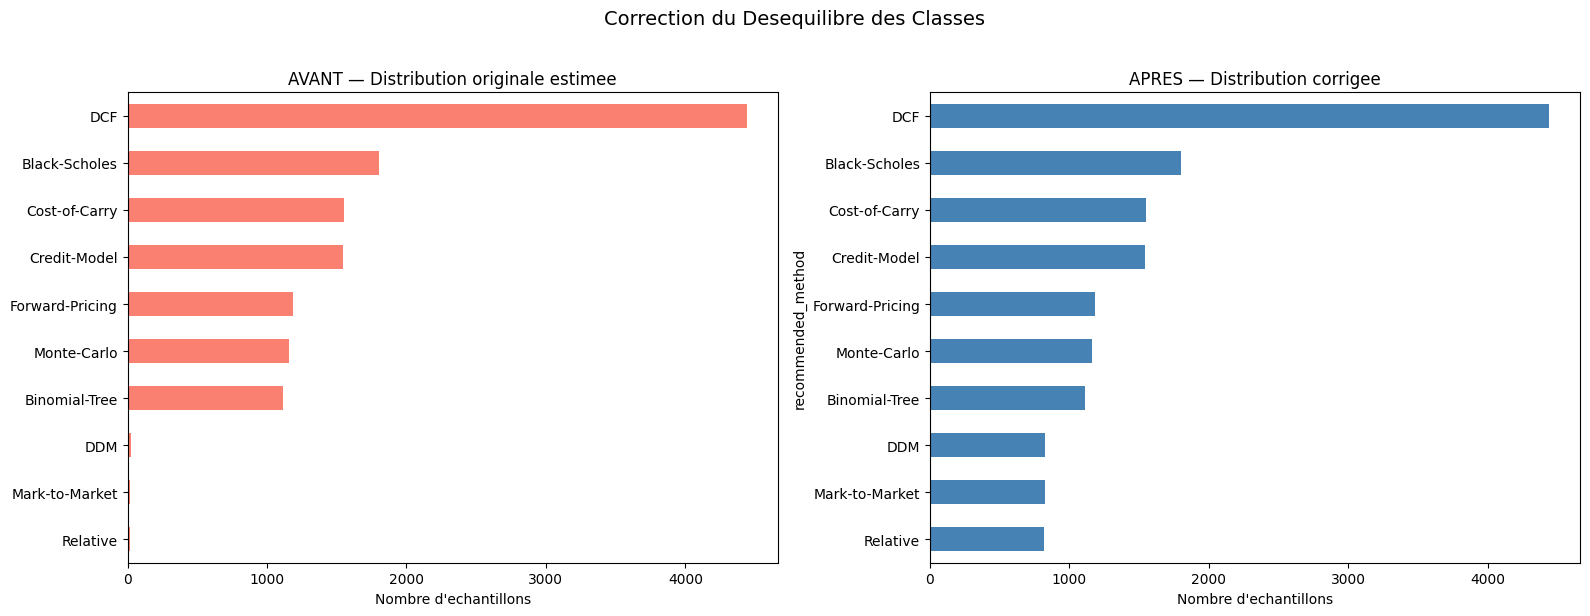

In [10]:
# ── Sauvegarder le dataset corrigé ─────────────────────────────
output_path = PROCESSED / "labeled_valuation_dataset_balanced.csv"
df_merged.to_csv(output_path, index=False)
print(f"Sauvegarde : {output_path}")
print(f"  {len(df_merged):,} lignes x {df_merged.shape[1]} colonnes")

# Visualiser la nouvelle distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Avant
ax = axes[0]
val_counts = pd.Series({
    "DCF": 888*5, "Black-Scholes": 360*5, "Cost-of-Carry": 311*5,
    "Credit-Model": 309*5, "Forward-Pricing": 237*5, "Monte-Carlo": 232*5,
    "Binomial-Tree": 223*5, "DDM": 5*5, "Mark-to-Market": 4*5, "Relative": 3*5,
})
val_counts.sort_values().plot(kind="barh", ax=ax, color="salmon")
ax.set_title("AVANT — Distribution originale estimee")
ax.set_xlabel("Nombre d'echantillons")

# Apres
ax2 = axes[1]
counts.sort_values().plot(kind="barh", ax=ax2, color="steelblue")
ax2.set_title("APRES — Distribution corrigee")
ax2.set_xlabel("Nombre d'echantillons")

plt.suptitle("Correction du Desequilibre des Classes", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "class_balance_correction.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Prochaines Étapes

Après avoir exécuté la régénération ci-dessus :

1. **Ré-exécuter le notebook `03_eda_and_feature_engineering.ipynb`** sur `labeled_valuation_dataset_balanced.csv`
   pour ré-enrichir et ré-encoder avec les nouvelles lignes

2. **Refaire le split train/val** (80/20 stratifié) — cette fois chaque classe aura
   assez d'échantillons pour un split propre

3. **Appliquer class_weight="balanced"** au lieu de SMOTE — avec ~800+ par classe,
   le class weighting suffit et évite les artefacts SMOTE

4. **Lancer `04_model_training.ipynb`** — Random Forest → XGBoost → CatBoost

Le ratio d'imbalance cible est **< 5:1** — suffisant pour que `class_weight="balanced"` fonctionne.
